# InfoGain 完整分析

分析Model 推理链（Thought + Action）对预测 tool_call 和 Action 的影响。

## 分析目标

1. **推理链价值评估**: 统计不同推理链对 tool_call 和 Action 的帮助
2. **Model  vs GT CoT 对比**: 评估Model 生成的 CoT 质量
3. **InfoGain 作为 RL Reward**: 探讨用 InfoGain 筛选 CoT 的可行性

## InfoGain 指标说明

### 对于预测 tool_call:
- `model_action_infogain`: Model  Action 的信息增益
- `model_thought_action_infogain`: Model  Thought+Action 的信息增益
- `gt_action_infogain`: GT Action 的信息增益
- `gt_thought_action_infogain`: GT Thought+Action 的信息增益
- `gt_full_infogain`: GT Full (Observation+Thought+Action) 的信息增益

### 对于预测 Action:
- `model_thought_to_action_infogain`: Model  Thought 对 Action 的信息增益
- `gt_thought_to_action_infogain`: GT Thought 对 Action 的信息增益
- `gt_full_to_action_infogain`: GT Full 对 Action 的信息增益

In [42]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# 设置 seaborn 样式
sns.set_style('whitegrid')

## 1. 数据加载和预处理

In [43]:
# 读取 InfoGain 结果
result_file = Path("../guir1/outputs/Qwen3-VL-4B-Instruct/analysis/agentnetbench_test_qwen3vl_sampling16_Thought:_infogain_multiGPU.json")

with open(result_file, 'r') as f:
    data = json.load(f)

print(f"总查询数: {data['summary']['total_queries']}")
print(f"总样本数: {data['summary']['total_samples']}")
print(f"详细结果数: {len(data['detailed_results'])}")

总查询数: 1208
总样本数: 19328
详细结果数: 1208


In [44]:
def fill_gt_perplexities(sample_infogains: List[Dict]) -> List[Dict]:
    """填充 GT 相关的 perplexity 值

    Ground truth 相关的对照组只在 sample_idx=0 时计算，
    需要将这些值复制到其他样本中。

    正确处理 inf, -inf, None, NaN 值。
    """
    import math

    def is_invalid_value(value):
        """检查值是否无效（inf, -inf, None, NaN）"""
        if value is None:
            return True
        if isinstance(value, float):
            if math.isinf(value) or math.isnan(value):
                return True
        return False

    # 找到 sample_idx=0 的 GT 值
    gt_values = None
    for sample in sample_infogains:
        if sample['sample_id'] == 0:
            gt_values = {
                'perplexity_gt_action_toolcall': sample.get('perplexity_gt_action_toolcall'),
                'perplexity_gt_thought_action_toolcall': sample.get('perplexity_gt_thought_action_toolcall'),
                'perplexity_gt_full_toolcall': sample.get('perplexity_gt_full_toolcall'),
                'perplexity_baseline_action': sample.get('perplexity_baseline_action'),
                'perplexity_gt_thought_action': sample.get('perplexity_gt_thought_action'),
                'perplexity_gt_full_action': sample.get('perplexity_gt_full_action'),
                'gt_action_infogain': sample.get('gt_action_infogain'),
                'gt_thought_action_infogain': sample.get('gt_thought_action_infogain'),
                'gt_full_infogain': sample.get('gt_full_infogain'),
                'gt_thought_to_action_infogain': sample.get('gt_thought_to_action_infogain'),
                'gt_full_to_action_infogain': sample.get('gt_full_to_action_infogain'),
            }
            break

    if gt_values is None:
        print("警告: 未找到 sample_idx=0 的 GT 值")
        return sample_infogains

    # 验证 sample_id=0 的值是否有效
    invalid_keys = [k for k, v in gt_values.items() if is_invalid_value(v)]
    if invalid_keys:
        print(f"警告: sample_id=0 中以下 GT 值无效: {invalid_keys}")
        print("这些值可能无法正确填充到其他样本")

    # 填充其他样本的 GT 值
    filled_samples = []
    for sample in sample_infogains:
        sample_copy = sample.copy()
        for key, value in gt_values.items():
            # 如果当前样本的值无效，用 sample_id=0 的值替换
            current_value = sample_copy.get(key)
            if is_invalid_value(current_value):
                sample_copy[key] = value
        sample_copy['model_thought_to_action_infogain'] = sample_copy.get('perplexity_baseline_action') - sample_copy.get('perplexity_model_thought_action')
        filled_samples.append(sample_copy)

    return filled_samples

# 填充所有 query 的 GT 值
for query_result in data['detailed_results']:
    query_result['sample_infogains'] = fill_gt_perplexities(query_result['sample_infogains'])

print("✓ GT perplexity 值已填充")

✓ GT perplexity 值已填充


In [45]:
# 将数据转换为 DataFrame 以便分析
rows = []
for query_result in data['detailed_results']:
    query_id = query_result['query_id']
    for sample in query_result['sample_infogains']:
        row = {'query_id': query_id}
        row.update(sample)
        rows.append(row)

df = pd.DataFrame(rows)

# 过滤掉无效样本（perplexity 为 inf 或 None）
df = df[df['perplexity_baseline_toolcall'] != float('inf')]
df = df[df['perplexity_baseline_toolcall'].notna()]

print(f"有效样本数: {len(df)}")
print(f"\数据列:")
print(df.columns.tolist())

有效样本数: 19328
\数据列:
['query_id', 'sample_id', 'perplexity_baseline_toolcall', 'perplexity_model_action_toolcall', 'perplexity_model_thought_action_toolcall', 'perplexity_gt_action_toolcall', 'perplexity_gt_thought_action_toolcall', 'perplexity_gt_full_toolcall', 'model_action_infogain', 'model_thought_action_infogain', 'gt_action_infogain', 'gt_thought_action_infogain', 'gt_full_infogain', 'perplexity_baseline_action', 'perplexity_model_thought_action', 'perplexity_gt_thought_action', 'perplexity_gt_full_action', 'model_thought_to_action_infogain', 'gt_thought_to_action_infogain', 'gt_full_to_action_infogain']


In [46]:
# 查看数据摘要
print("=" * 80)
print("InfoGain 统计摘要")
print("=" * 80)

infogain_cols = [
    'model_action_infogain',
    'model_thought_action_infogain',
    'gt_action_infogain',
    'gt_thought_action_infogain',
    'gt_full_infogain',
    'model_thought_to_action_infogain',
    'gt_thought_to_action_infogain',
    'gt_full_to_action_infogain',
]

df[infogain_cols].describe()

InfoGain 统计摘要


,model_action_infogain,model_thought_action_infogain,gt_action_infogain,gt_thought_action_infogain,gt_full_infogain,model_thought_to_action_infogain,gt_thought_to_action_infogain,gt_full_to_action_infogain
count,19328.000000,19328.000000,19328.000000,19328.000000,19328.000000,1.932800e+04,19328.000000,19328.000000
mean,-0.219277,-0.250899,0.182136,0.275838,0.274216,-1.417536e+05,14.271000,14.839524
std,0.667780,0.727519,0.597401,0.551973,0.551776,5.437158e+06,277.831238,282.895374
min,-9.122637,-9.846302,-7.202608,-2.311520,-3.184350,-5.051361e+08,-20.949018,-19.092813
25%,-0.367316,-0.402052,-0.011818,0.018695,0.020978,-1.711602e+01,-0.004091,0.133983
50%,-0.029313,-0.050516,0.072724,0.127174,0.130583,-7.286890e+00,0.880943,1.162454
75%,0.073558,0.061392,0.276009,0.337255,0.335459,-3.572851e+00,3.636114,4.252879
max,3.711368,3.783427,6.803746,6.817113,6.773224,3.525678e+05,9606.354980,9782.944824


## 2. 推理链价值分析

### 2.1 对于 tool_call 的推理链价值

In [ ]:
def classify_toolcall_benefit(row) -> str:
    """根据不同推理链的 InfoGain 分类样本受益类型"""
    threshold = 0.000000001
    
    model_action_benefit = row['model_action_infogain'] > threshold
    model_thought_action_benefit = row['model_thought_action_infogain'] > threshold
    model_thought_benefit = (row['model_thought_action_infogain'] - row['model_action_infogain']) > threshold
    gt_action_benefit = row['gt_action_infogain'] > threshold
    gt_thought_action_benefit = row['gt_thought_action_infogain'] > threshold
    gt_thought_benefit = (row['gt_thought_action_infogain'] - row['gt_action_infogain']) > threshold
    gt_full_benefit = row['gt_full_infogain'] > threshold
    gt_observation_benefit = (row['gt_full_infogain'] - row['gt_thought_action_infogain']) > threshold
    
    benefits = [model_action_benefit, model_thought_action_benefit, gt_action_benefit, gt_thought_action_benefit, gt_full_benefit,
                model_thought_benefit, gt_thought_benefit, gt_observation_benefit]
    # benefit_count = sum(benefits)
    
    tag = ""
    if  model_action_benefit:
        tag += "M-Action+"
    if model_thought_action_benefit:
        tag += "M-combine-Thought+Action+"
    if model_thought_benefit:
        tag += "M-Thought+"
    if gt_action_benefit:
        tag += "GT-Action+"
    if gt_thought_action_benefit:
        tag += "GT-combine-Thought+Action+"
    if gt_thought_benefit:
        tag += "GT-Thought+"
    if gt_full_benefit:
        tag += "GT-Full+"
    if gt_observation_benefit:
        tag += "GT-Observation+"
    if tag == "":
        tag = "无增益"
    else:
        tag = tag[:-1]  # 去掉最后的 '+'
    return tag

    # if benefit_count == 0:
    #     return "无增益"
    # elif benefit_count == 1:
    #     if model_action_benefit:
    #         return "仅Model Action有益"
    #     elif model_thought_action_benefit:
    #         return "仅Model Thought+Action有益"
    #     elif gt_action_benefit:
    #         return "仅GT Action有益"
    #     elif gt_thought_action_benefit:
    #         return "仅GT Thought+Action有益"
    #     else:
    #         return "仅GT Full有益"
    # else:
    #     return "混合受益"

df['toolcall_benefit_type'] = df.apply(classify_toolcall_benefit, axis=1)

# 统计各类型数量
benefit_counts = df['toolcall_benefit_type'].value_counts()
benefit_percentages = df['toolcall_benefit_type'].value_counts(normalize=True) * 100

# print("=" * 80)
# print("对于 tool_call 的推理链受益类型统计")
# print("=" * 80)
# for benefit_type in benefit_counts.index:
#     count = benefit_counts[benefit_type]
#     pct = benefit_percentages[benefit_type]
#     print(f"{benefit_type:30s}: {count:4d} ({pct:5.2f}%)")

gt_action_matter_counts = 0
model_action_matter_counts = 0
gt_thought_help_counts = 0
model_thought_help_counts = 0
observation_help_counts = 0
for benefit_type in benefit_counts.index:
    if "M-Action" in benefit_type:# 'GT-Action' in benefit_type:# or "M-Action" in benefit_type:
        model_action_matter_counts += benefit_counts[benefit_type]
    if "M-Thought" in benefit_type:# 'GT-Thought' in benefit_type: # or "M-Thought" in benefit_type:
        model_thought_help_counts += benefit_counts[benefit_type]
    if "GT-Action" in benefit_type:
        gt_action_matter_counts += benefit_counts[benefit_type]
    if "GT-Thought" in benefit_type:
        gt_thought_help_counts += benefit_counts[benefit_type]
    if 'GT-Observation' in benefit_type:
        observation_help_counts += benefit_counts[benefit_type]
print(f"Model  Action 带来增益的样本数: {model_action_matter_counts} ({model_action_matter_counts/len(df)*100:.2f}%)")
print(f"Model  Thought 带来增益的样本数: {model_thought_help_counts} ({model_thought_help_counts/len(df)*100:.2f}%)")
print(f"GT Action 带来增益的样本数: {gt_action_matter_counts} ({gt_action_matter_counts/len(df)*100:.2f}%)")
print(f"GT Thought 带来增益的样本数: {gt_thought_help_counts} ({gt_thought_help_counts/len(df)*100:.2f}%)")
print(f"Observation 带来增益的样本数: {observation_help_counts} ({observation_help_counts/len(df)*100:.2f}%)")

模型 Action 带来增益的样本数: 8504 (44.00%)
模型 Thought 带来增益的样本数: 7031 (36.38%)
GT Action 带来增益的样本数: 13920 (72.02%)
GT Thought 带来增益的样本数: 12832 (66.39%)
Observation 带来增益的样本数: 9968 (51.57%)


In [48]:
# 统计row['gt_action_infogain']和(row['gt_thought_action_infogain'] - row['gt_action_infogain'])的均值
mean_gt_action_infogain = df['gt_action_infogain'].mean()
mean_gt_thought_to_action_infogain = (df['gt_thought_action_infogain'] - df['gt_action_infogain']).mean()
mean_gt_tool_call_perplexity = df['perplexity_baseline_toolcall'].mean()
print(f"GT Tool Call Perplexity均值: {mean_gt_tool_call_perplexity:.4f}")
print(f"GT Action InfoGain均值: {mean_gt_action_infogain:.4f}")
print(f"GT Thought to Action InfoGain均值: {mean_gt_thought_to_action_infogain:.4f}")

GT Tool Call Perplexity均值: 1.6508
GT Action InfoGain均值: 0.1821
GT Thought to Action InfoGain均值: 0.0937


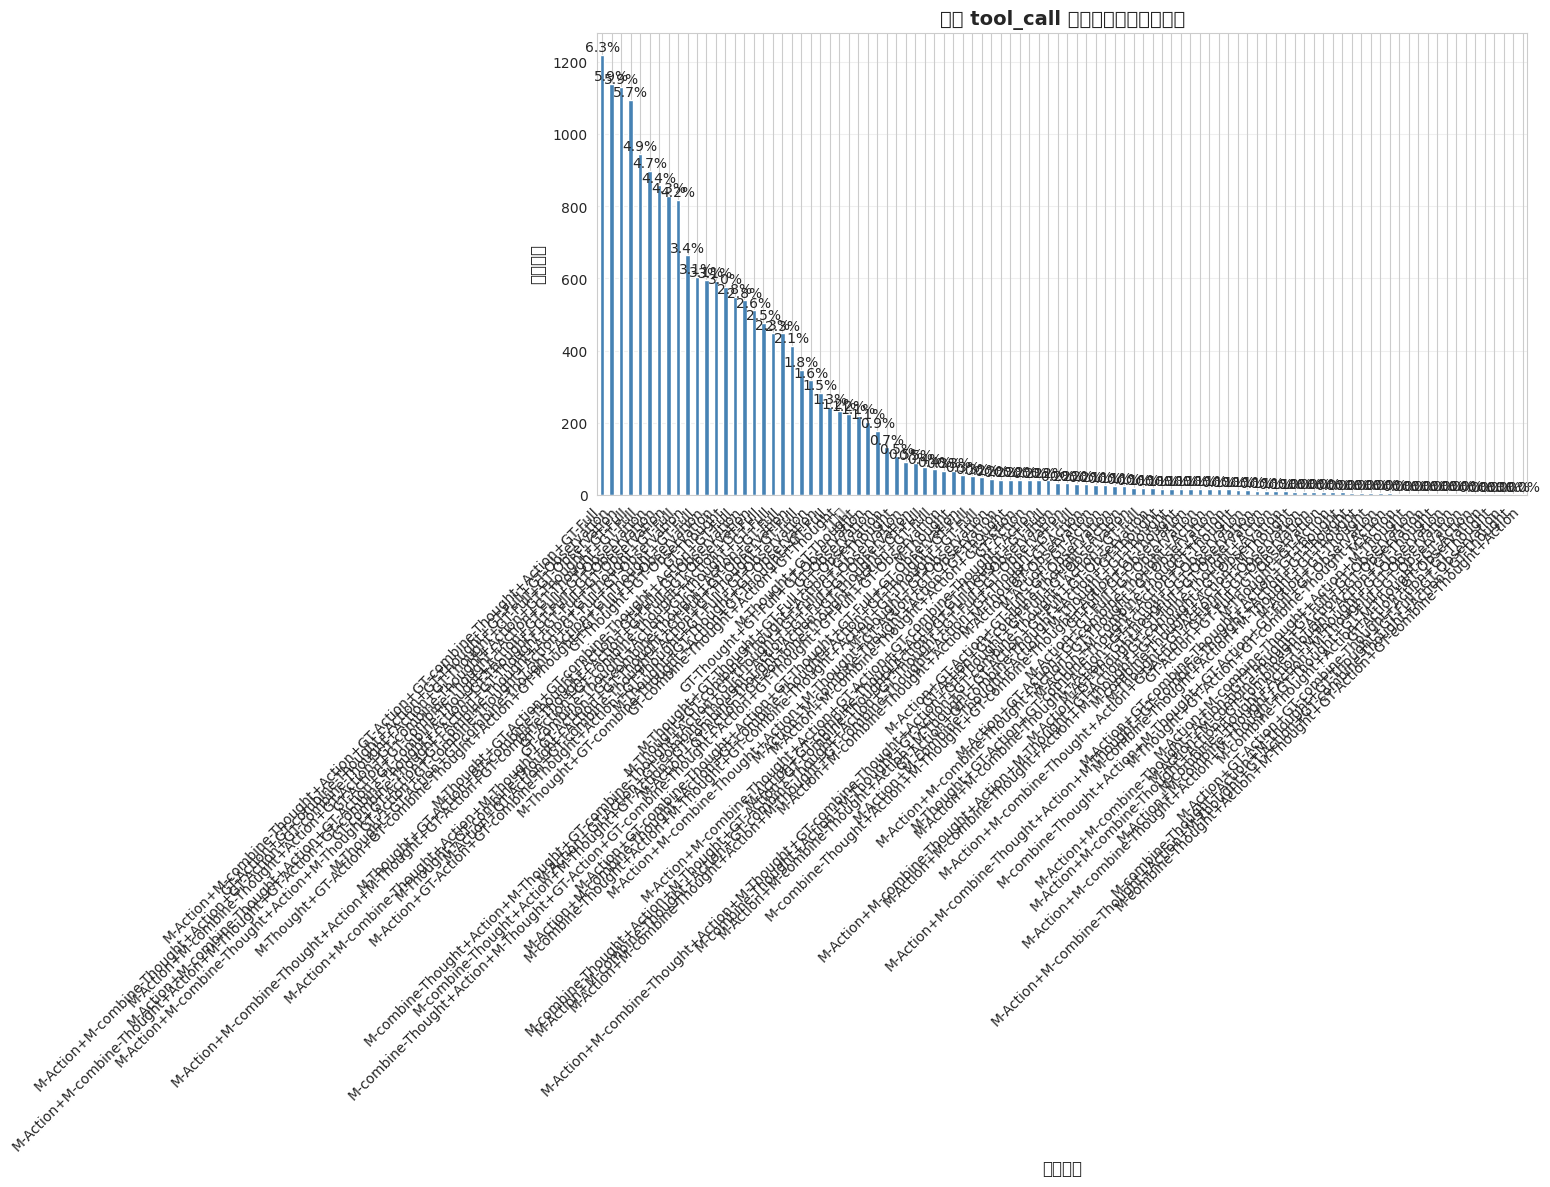

In [49]:
# 可视化：tool_call 推理链受益类型分布
fig, ax = plt.subplots(figsize=(12, 6))
benefit_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('对于 tool_call 的推理链受益类型分布', fontsize=14, fontweight='bold')
ax.set_xlabel('受益类型', fontsize=12)
ax.set_ylabel('样本数量', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# 添加百分比标注
for i, (count, pct) in enumerate(zip(benefit_counts, benefit_percentages)):
    ax.text(i, count + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 对于 Action 的推理链价值

In [ ]:
def classify_action_benefit(row) -> str:
    """对于 Action 的 Thought 受益类型"""
    threshold = 0.05
    if pd.isna(row['model_thought_to_action_infogain']):
        return "无Action数据"

    model_thought_benefit = row['model_thought_to_action_infogain'] > threshold
    gt_thought_benefit = row['gt_thought_to_action_infogain'] > threshold if not pd.isna(row['gt_thought_to_action_infogain']) else False
    gt_full_benefit = row['gt_full_to_action_infogain'] > threshold if not pd.isna(row['gt_full_to_action_infogain']) else False
    gt_observation_benefit = (row['gt_full_to_action_infogain'] - row['gt_thought_to_action_infogain']) > threshold


    benefits = [model_thought_benefit, gt_thought_benefit, gt_full_benefit]
    benefit_count = sum(benefits)

    # if benefit_count == 0:
    #     return "无增益"
    # elif benefit_count == 1:
    #     if model_thought_benefit:
    #         return "仅Model Thought有益"
    #     elif gt_thought_benefit:
    #         return "仅GT Thought有益"
    #     else:
    #         return "仅GT Full有益"
    # else:
    #     return "混合受益"
    tag = ""
    if model_thought_benefit:
        tag += "M-Thought+"
    if gt_thought_benefit:
        tag += "GT-Thought+"
    if gt_observation_benefit:
        tag += "GT-Observation+"
    if tag == "":
        tag = "无增益"
    else:
        tag = tag[:-1]  # 去掉最后的 '+'
    return tag
  
df['action_benefit_type'] = df.apply(classify_action_benefit, axis=1)

print("=" * 80)
print("对于 Action 的推理链受益类型统计")
print("=" * 80)
print(df['action_benefit_type'].value_counts())
print("\百分比:")
print(df['action_benefit_type'].value_counts(normalize=True) * 100)

对于 Action 的推理链受益类型统计
action_benefit_type
GT-Thought+GT-Observation              9271
GT-Thought                             4412
GT-Observation                         3555
无增益                                    1787
M-Thought+GT-Thought                    148
M-Thought+GT-Thought+GT-Observation     121
M-Thought                                21
M-Thought+GT-Observation                 13
Name: count, dtype: int64
\百分比:
action_benefit_type
GT-Thought+GT-Observation              47.966680
GT-Thought                             22.826987
GT-Observation                         18.393005
无增益                                     9.245654
M-Thought+GT-Thought                    0.765728
M-Thought+GT-Thought+GT-Observation     0.626035
M-Thought                               0.108651
M-Thought+GT-Observation                0.067260
Name: proportion, dtype: float64


In [ ]:
gt_thought_matter_counts = 0
gt_observation_matter_counts = 0
model_thought_matter_counts = 0
for benefit_type in df['action_benefit_type'].value_counts().index:
    if "M-Thought" in benefit_type:# 'GT-Thought' in benefit_type:# or "M-Thought" in benefit_type:
        model_thought_matter_counts += df['action_benefit_type'].value_counts()[benefit_type]
    if "GT-Thought" in benefit_type:
        gt_thought_matter_counts += df['action_benefit_type'].value_counts()[benefit_type]
    if 'GT-Observation' in benefit_type:
        gt_observation_matter_counts += df['action_benefit_type'].value_counts()[benefit_type]
print(f"Model  Thought 带来增益的样本数: {model_thought_matter_counts} ({model_thought_matter_counts/len(df)*100:.2f}%)")
print(f"GT Thought 带来增益的样本数: {gt_thought_matter_counts} ({gt_thought_matter_counts/len(df)*100:.2f}%)")
print(f"Observation 带来增益的样本数: {gt_observation_matter_counts} ({gt_observation_matter_counts/len(df)*100:.2f}%)")

模型 Thought 带来增益的样本数: 303 (1.57%)
GT Thought 带来增益的样本数: 13952 (72.19%)
Observation 带来增益的样本数: 12960 (67.05%)


## 3. Model  vs GT 对比分析

In [ ]:
# Action InfoGain 对比
print("=" * 80)
print("Model  Action vs GT Action (对于 tool_call)")
print("=" * 80)

model_action_mean = df['model_action_infogain'].mean()
gt_action_mean = df['gt_action_infogain'].mean()

print(f"Model  Action InfoGain 平均值: {model_action_mean:.4f}")
print(f"GT Action InfoGain 平均值: {gt_action_mean:.4f}")
print(f"差距: {gt_action_mean - model_action_mean:.4f}")
print(f"Model 相对GT的比例: {(model_action_mean / gt_action_mean * 100):.2f}%")

# 统计Model 优于 GT 的样本
model_better = (df['model_action_infogain'] > df['gt_action_infogain']).sum()
gt_better = (df['gt_action_infogain'] > df['model_action_infogain']).sum()

print(f"Model  Action 优于 GT: {model_better} ({model_better/len(df)*100:.2f}%)")
print(f"GT Action 优于Model : {gt_better} ({gt_better/len(df)*100:.2f}%)")

# Thought+Action InfoGain 对比
print("=" * 80)
print("Model  Thought+Action vs GT Thought+Action (对于 tool_call)")
print("=" * 80)

model_ta_mean = df['model_thought_action_infogain'].mean()
gt_ta_mean = df['gt_thought_action_infogain'].mean()

print(f"Model  Thought+Action InfoGain 平均值: {model_ta_mean:.4f}")
print(f"GT Thought+Action InfoGain 平均值: {gt_ta_mean:.4f}")
print(f"差距: {gt_ta_mean - model_ta_mean:.4f}")
print(f"Model 相对GT的比例: {(model_ta_mean / gt_ta_mean * 100):.2f}%")

model_better_ta = (df['model_thought_action_infogain'] > df['gt_thought_action_infogain']).sum()
gt_better_ta = (df['gt_thought_action_infogain'] > df['model_thought_action_infogain']).sum()

print(f"Model  Thought+Action 优于 GT: {model_better_ta} ({model_better_ta/len(df)*100:.2f}%)")
print(f"GT Thought+Action 优于Model : {gt_better_ta} ({gt_better_ta/len(df)*100:.2f}%)")

模型 Action vs GT Action (对于 tool_call)
模型 Action InfoGain 平均值: -0.2193
GT Action InfoGain 平均值: 0.1821
差距: 0.4014
模型相对GT的比例: -120.39%
模型 Action 优于 GT: 5274 (27.29%)
GT Action 优于模型: 13073 (67.64%)
模型 Thought+Action vs GT Thought+Action (对于 tool_call)
模型 Thought+Action InfoGain 平均值: -0.2509
GT Thought+Action InfoGain 平均值: 0.2758
差距: 0.5267
模型相对GT的比例: -90.96%
模型 Thought+Action 优于 GT: 3071 (15.89%)
GT Thought+Action 优于模型: 15768 (81.58%)


## 4. Model  vs GT 散点图对比

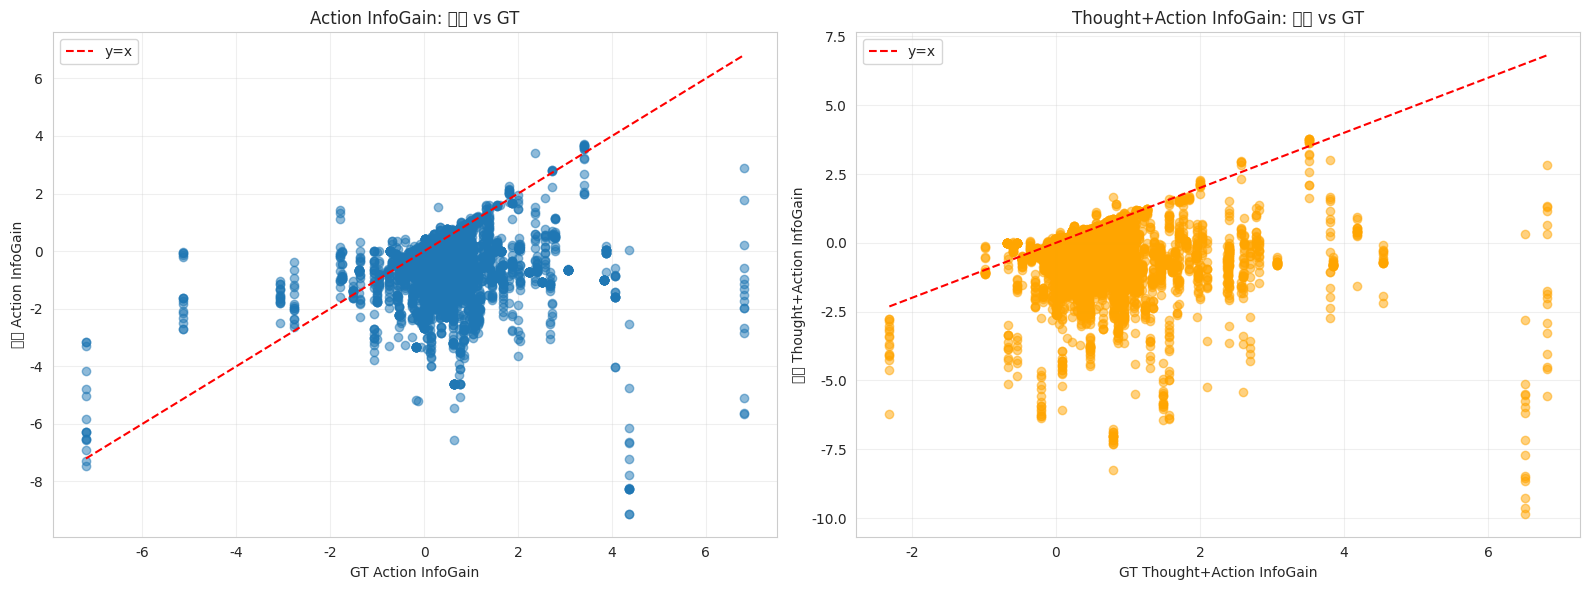

In [ ]:
# Model  vs GT InfoGain 散点图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Action InfoGain
axes[0].scatter(df['gt_action_infogain'], df['model_action_infogain'], alpha=0.5)
axes[0].plot([df['gt_action_infogain'].min(), df['gt_action_infogain'].max()],
             [df['gt_action_infogain'].min(), df['gt_action_infogain'].max()],
             'r--', label='y=x')
axes[0].set_xlabel('GT Action InfoGain')
axes[0].set_ylabel('Model  Action InfoGain')
axes[0].set_title('Action InfoGain: Model  vs GT')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Thought+Action InfoGain
axes[1].scatter(df['gt_thought_action_infogain'], df['model_thought_action_infogain'],
               alpha=0.5, color='orange')
axes[1].plot([df['gt_thought_action_infogain'].min(), df['gt_thought_action_infogain'].max()],
             [df['gt_thought_action_infogain'].min(), df['gt_thought_action_infogain'].max()],
             'r--', label='y=x')
axes[1].set_xlabel('GT Thought+Action InfoGain')
axes[1].set_ylabel('Model  Thought+Action InfoGain')
axes[1].set_title('Thought+Action InfoGain: Model  vs GT')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 双方都无增益的样本分析

In [61]:
# 分析这些样本是否是因为任务太简单
print(f"\与全体样本对比:")
print(f"全体平均 baseline perplexity: {df['perplexity_baseline_toolcall'].mean():.4f}")
print(f"全体平均 gt action perplexity: {df['perplexity_gt_action_toolcall'].mean():.4f}")
print(f"全体平均 gt thought+action perplexity: {df['perplexity_gt_thought_action_toolcall'].mean():.4f}")
print(f"全体平均 gt full perplexity: {df['perplexity_gt_full_toolcall'].mean():.4f}")
print(f"全体平均 model action perplexity: {df['perplexity_model_action_toolcall'].mean():.4f}")
print(f"全体平均 model thought+action perplexity: {df['perplexity_model_thought_action_toolcall'].mean():.4f}")
print(f"全体平均 perplexity_baseline_action: {df['perplexity_baseline_action'].mean():.4f}")
print(f"全体平均 perplexity_model_thought_action: {df['perplexity_model_thought_action'].mean():.4f}")
print(f"全体平均 perplexity_gt_thought_action: {df['perplexity_gt_thought_action'].mean():.4f}")
print(f"全体平均 perplexity_gt_full_action: {df['perplexity_gt_full_action'].mean():.4f}")

\与全体样本对比:
全体平均 baseline perplexity: 1.6508
全体平均 gt action perplexity: 1.4687
全体平均 gt thought+action perplexity: 1.3750
全体平均 gt full perplexity: 1.3766
全体平均 model action perplexity: 1.8701
全体平均 model thought+action perplexity: 1.9017
全体平均 perplexity_baseline_action: 1715.6477
全体平均 perplexity_model_thought_action: 143469.2056
全体平均 perplexity_gt_thought_action: 1701.3767
全体平均 perplexity_gt_full_action: 1700.8082


In [ ]:
# 找出双方 Thought 都无增益的样本
threshold = 0.00001

both_no_benefit_toolcall = df[
    (df['model_thought_action_infogain'] <= threshold) &
    (df['gt_thought_action_infogain'] <= threshold)
]

print("=" * 80)
print("Model 和GT的Thought+Action都无增益的样本 (对于 tool_call)")
print("=" * 80)
print(f"样本数: {len(both_no_benefit_toolcall)} ({len(both_no_benefit_toolcall)/len(df)*100:.2f}%)")
print(f"\这些样本的特征:")
print(f"平均 baseline perplexity: {both_no_benefit_toolcall['perplexity_baseline_toolcall'].mean():.4f}")
print(f"平均 gt action perplexity: {both_no_benefit_toolcall['perplexity_gt_action_toolcall'].mean():.4f}")
print(f"平均 gt thought+action perplexity: {both_no_benefit_toolcall['perplexity_gt_thought_action_toolcall'].mean():.4f}")
print(f"平均 gt full perplexity: {both_no_benefit_toolcall['perplexity_gt_full_toolcall'].mean():.4f}")
print(f"平均 model action perplexity: {both_no_benefit_toolcall['perplexity_model_action_toolcall'].mean():.4f}")
print(f"平均 model thought+action perplexity: {both_no_benefit_toolcall['perplexity_model_thought_action_toolcall'].mean():.4f}")

模型和GT的Thought+Action都无增益的样本 (对于 tool_call)
样本数: 2835 (14.67%)
\这些样本的特征:
平均 baseline perplexity: 1.4666
平均 gt action perplexity: 1.6980
平均 gt thought+action perplexity: 1.5604
平均 gt full perplexity: 1.5679
平均 model action perplexity: 1.7405
平均 model thought+action perplexity: 1.8000


In [ ]:
# 找出双方 Action 都无增益的样本
threshold = 0.00001

both_no_benefit_toolcall = df[
    (df['model_action_infogain'] <= threshold) &
    (df['gt_action_infogain'] <= threshold)
]

print("=" * 80)
print("Model 和GT的Action都无增益的样本 (对于 tool_call)")
print("=" * 80)
print(f"样本数: {len(both_no_benefit_toolcall)} ({len(both_no_benefit_toolcall)/len(df)*100:.2f}%)")
print(f"\这些样本的特征:")
print(f"平均 baseline perplexity: {both_no_benefit_toolcall['perplexity_baseline_toolcall'].mean():.4f}")
print(f"平均 gt action perplexity: {both_no_benefit_toolcall['perplexity_gt_action_toolcall'].mean():.4f}")
print(f"平均 gt thought+action perplexity: {both_no_benefit_toolcall['perplexity_gt_thought_action_toolcall'].mean():.4f}")
print(f"平均 gt full perplexity: {both_no_benefit_toolcall['perplexity_gt_full_toolcall'].mean():.4f}")
print(f"平均 model action perplexity: {both_no_benefit_toolcall['perplexity_model_action_toolcall'].mean():.4f}")
print(f"平均 model thought+action perplexity: {both_no_benefit_toolcall['perplexity_model_thought_action_toolcall'].mean():.4f}")

模型和GT的Action都无增益的样本 (对于 tool_call)
样本数: 5092 (26.35%)
\这些样本的特征:
平均 baseline perplexity: 1.6324
平均 gt action perplexity: 1.8369
平均 gt thought+action perplexity: 1.6216
平均 gt full perplexity: 1.6304
平均 model action perplexity: 1.9370
平均 model thought+action perplexity: 1.9854


In [ ]:
# 找出Observation, Thought, Action 都无增益的样本
threshold = 0.00001

both_no_benefit_toolcall = df[
    (df['model_action_infogain'] <= threshold) &
    (df['gt_action_infogain'] <= threshold) & 
    (df['gt_full_infogain'] <= threshold)
]

print("=" * 80)
print("Model 和GT的Observation, Thought, Action 都无增益的样本 (对于 tool_call)")
print("=" * 80)
print(f"样本数: {len(both_no_benefit_toolcall)} ({len(both_no_benefit_toolcall)/len(df)*100:.2f}%)")
print(f"\这些样本的特征:")
print(f"平均 baseline perplexity: {both_no_benefit_toolcall['perplexity_baseline_toolcall'].mean():.4f}")
print(f"平均 gt action perplexity: {both_no_benefit_toolcall['perplexity_gt_action_toolcall'].mean():.4f}")
print(f"平均 gt thought+action perplexity: {both_no_benefit_toolcall['perplexity_gt_thought_action_toolcall'].mean():.4f}")
print(f"平均 gt full perplexity: {both_no_benefit_toolcall['perplexity_gt_full_toolcall'].mean():.4f}")
print(f"平均 model action perplexity: {both_no_benefit_toolcall['perplexity_model_action_toolcall'].mean():.4f}")
print(f"平均 model thought+action perplexity: {both_no_benefit_toolcall['perplexity_model_thought_action_toolcall'].mean():.4f}")

模型和GT的Observation, Thought, Action 都无增益的样本 (对于 tool_call)
样本数: 2664 (13.78%)
\这些样本的特征:
平均 baseline perplexity: 1.5121
平均 gt action perplexity: 1.7616
平均 gt thought+action perplexity: 1.5996
平均 gt full perplexity: 1.6258
平均 model action perplexity: 1.8043
平均 model thought+action perplexity: 1.8641


In [ ]:
# 找出Observation, Thought, Action 都无增益的样本
threshold = 0.00001

both_no_benefit_toolcall = df[
    (df['model_thought_to_action_infogain'] <= threshold) &
    (df['gt_thought_to_action_infogain'] <= threshold) & 
    (df['gt_full_to_action_infogain'] <= threshold)
]

print("=" * 80)
print("Model 和GT的Observation, Thought都无增益的样本 (对于 Action)")
print("=" * 80)
print(f"样本数: {len(both_no_benefit_toolcall)} ({len(both_no_benefit_toolcall)/len(df)*100:.2f}%)")
print(f"\这些样本的特征:")
print(f"平均 baseline perplexity: {both_no_benefit_toolcall['perplexity_baseline_toolcall'].mean():.4f}")
print(f"平均 perplexity_baseline_action: {both_no_benefit_toolcall['perplexity_baseline_action'].mean():.4f}")

模型和GT的Observation, Thought都无增益的样本 (对于 Action)
样本数: 3660 (18.94%)
\这些样本的特征:
平均 baseline perplexity: 1.4638
平均 perplexity_baseline_action: 7111.8070


In [ ]:
# 找出Observation, Thought, Action 都无增益的样本
threshold = 0.00001

both_no_benefit_toolcall = df[
    (df['model_thought_to_action_infogain'] <= threshold) &
    (df['gt_thought_to_action_infogain'] <= threshold)
]

print("=" * 80)
print("Model 和GT的Thought都无增益的样本 (对于 Action)")
print("=" * 80)
print(f"样本数: {len(both_no_benefit_toolcall)} ({len(both_no_benefit_toolcall)/len(df)*100:.2f}%)")
print(f"\这些样本的特征:")
print(f"平均 baseline perplexity: {both_no_benefit_toolcall['perplexity_baseline_toolcall'].mean():.4f}")
print(f"平均 perplexity_baseline_action: {both_no_benefit_toolcall['perplexity_baseline_action'].mean():.4f}")

模型和GT的Thought都无增益的样本 (对于 Action)
样本数: 4972 (25.72%)
\这些样本的特征:
平均 baseline perplexity: 1.4651
平均 perplexity_baseline_action: 5236.1868


## 6. InfoGain 分布分析

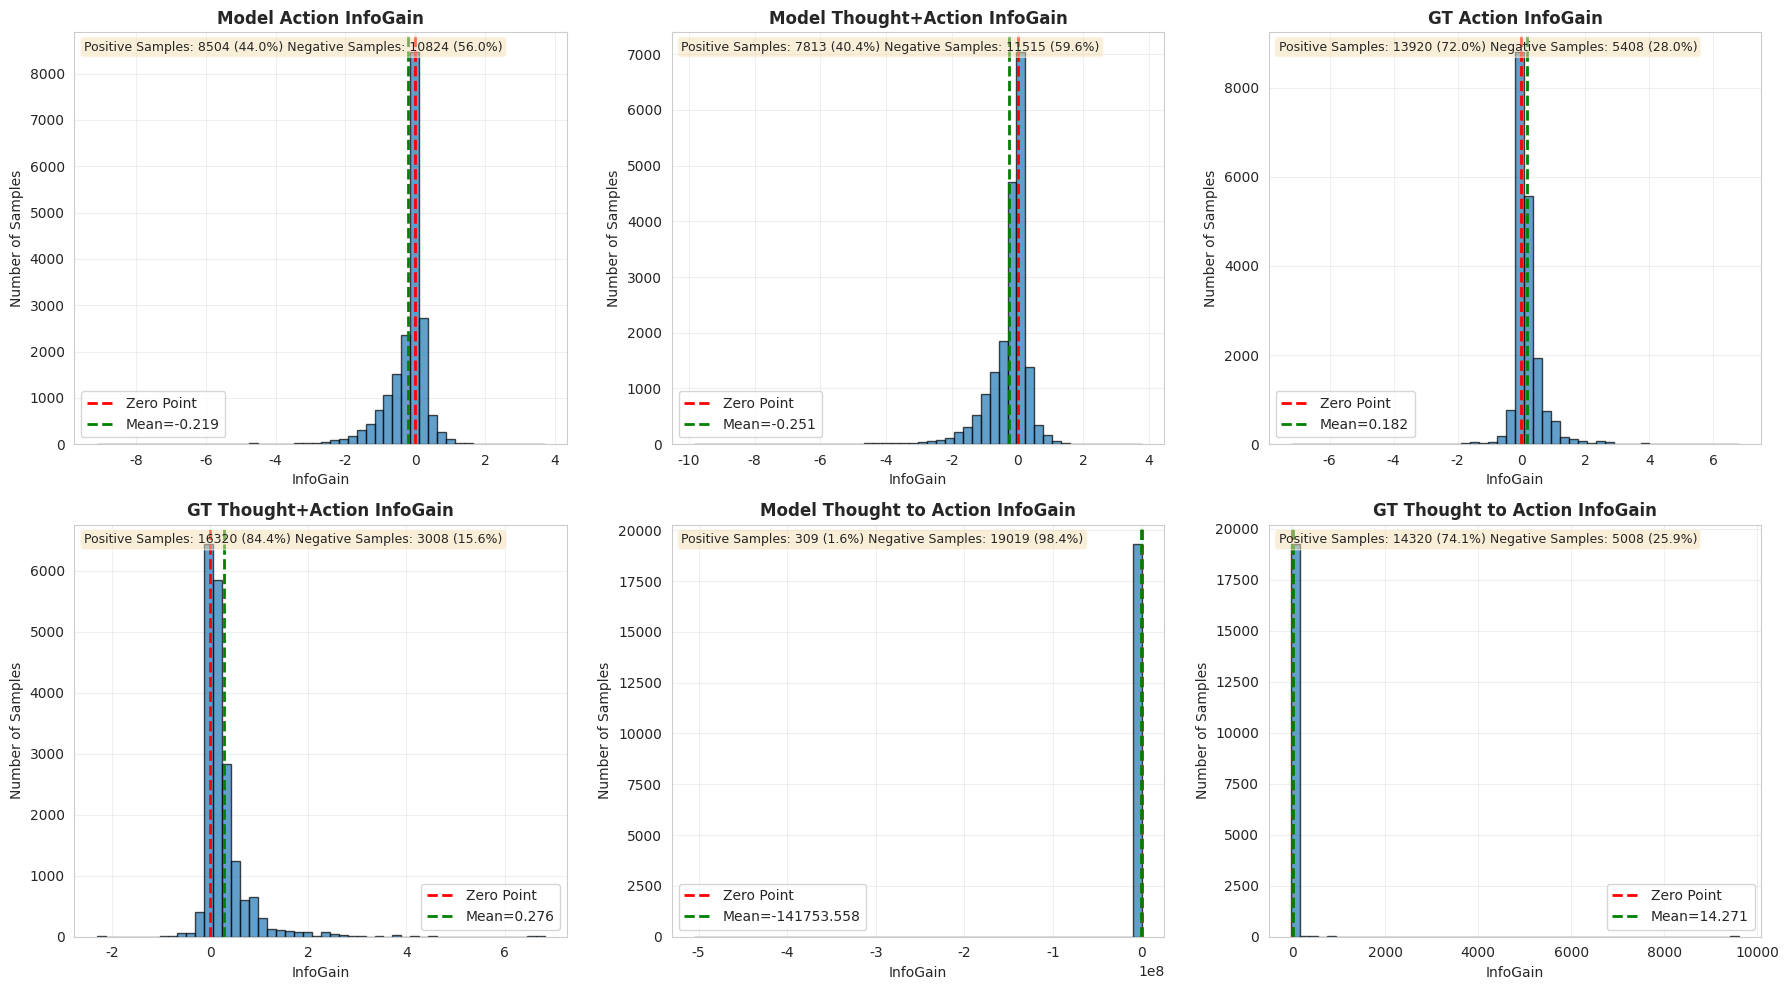

In [69]:
# InfoGain 分布直方图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

infogain_metrics = [
    ('model_action_infogain', 'Model Action InfoGain'),
    ('model_thought_action_infogain', 'Model Thought+Action InfoGain'),
    ('gt_action_infogain', 'GT Action InfoGain'),
    ('gt_thought_action_infogain', 'GT Thought+Action InfoGain'),
    ('model_thought_to_action_infogain', 'Model Thought to Action InfoGain'),
    ('gt_thought_to_action_infogain', 'GT Thought to Action InfoGain'),
]

for idx, (col, title) in enumerate(infogain_metrics):
    ax = axes[idx // 3, idx % 3]
    data = df[col].dropna()

    ax.hist(data, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Point')
    ax.axvline(data.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean={data.mean():.3f}')
    ax.set_xlabel('InfoGain')
    ax.set_ylabel('Number of Samples')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    # 统计正负样本
    positive = (data > 0).sum()
    negative = (data <= 0).sum()
    ax.text(0.02, 0.98, f'Positive Samples: {positive} ({positive/len(data)*100:.1f}%) Negative Samples: {negative} ({negative/len(data)*100:.1f}%)',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Thought 增量价值分析

In [71]:
# Thought 增量价值分析
df['model_thought_incremental'] = df['model_thought_action_infogain'] - df['model_action_infogain']
df['gt_thought_incremental'] = df['gt_thought_action_infogain'] - df['gt_action_infogain']

print("=" * 80)
print("Thought 增量价值分析")
print("=" * 80)

# Model  Thought 增量
model_thought_positive = (df['model_thought_incremental'] > 0.05).sum()
model_thought_negative = (df['model_thought_incremental'] < -0.05).sum()
model_thought_neutral = len(df) - model_thought_positive - model_thought_negative

print(f"Model  Thought 增量价值:")
print(f"  有额外价值（>0.05）: {model_thought_positive} ({model_thought_positive/len(df)*100:.1f}%)")
print(f"  有负面影响（<-0.05）: {model_thought_negative} ({model_thought_negative/len(df)*100:.1f}%)")
print(f"  基本无影响: {model_thought_neutral} ({model_thought_neutral/len(df)*100:.1f}%)")
print(f"  平均增量: {df['model_thought_incremental'].mean():.4f}")

# GT Thought 增量
gt_thought_positive = (df['gt_thought_incremental'] > 0.05).sum()
gt_thought_negative = (df['gt_thought_incremental'] < -0.05).sum()
gt_thought_neutral = len(df) - gt_thought_positive - gt_thought_negative

print(f"\GT Thought 增量价值:")
print(f"  有额外价值（>0.05）: {gt_thought_positive} ({gt_thought_positive/len(df)*100:.1f}%)")
print(f"  有负面影响（<-0.05）: {gt_thought_negative} ({gt_thought_negative/len(df)*100:.1f}%)")
print(f"  基本无影响: {gt_thought_neutral} ({gt_thought_neutral/len(df)*100:.1f}%)")
print(f"  平均增量: {df['gt_thought_incremental'].mean():.4f}")

Thought 增量价值分析
Model  Thought 增量价值:
  有额外价值（>0.05）: 3099 (16.0%)
  有负面影响（<-0.05）: 5708 (29.5%)
  基本无影响: 10521 (54.4%)
  平均增量: -0.0316
\GT Thought 增量价值:
  有额外价值（>0.05）: 7120 (36.8%)
  有负面影响（<-0.05）: 416 (2.2%)
  基本无影响: 11792 (61.0%)
  平均增量: 0.0937


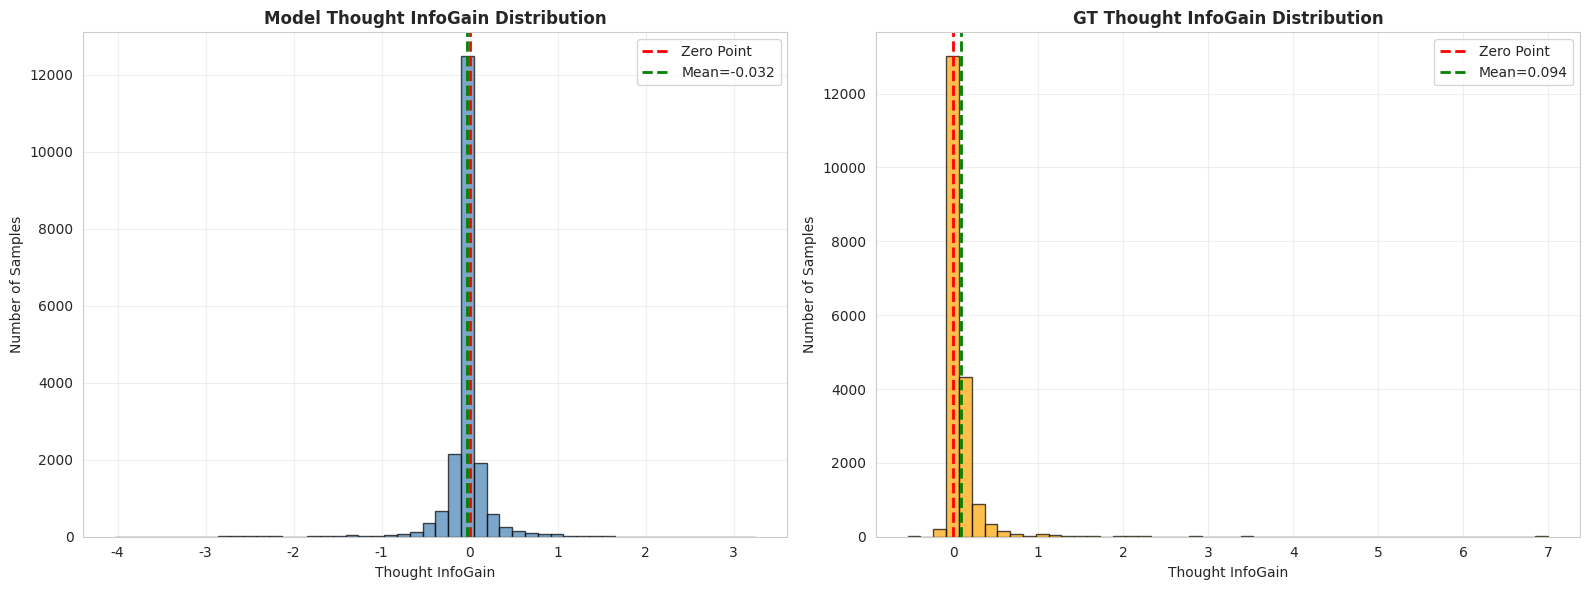

In [72]:
# Thought 增量分布可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model  Thought 增量
axes[0].hist(df['model_thought_incremental'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Point')
axes[0].axvline(df['model_thought_incremental'].mean(), color='green', linestyle='--', 
               linewidth=2, label=f"Mean={df['model_thought_incremental'].mean():.3f}")
axes[0].set_xlabel('Thought InfoGain')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Model Thought InfoGain Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# GT Thought 增量
axes[1].hist(df['gt_thought_incremental'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Point')
axes[1].axvline(df['gt_thought_incremental'].mean(), color='green', linestyle='--',
               linewidth=2, label=f"Mean={df['gt_thought_incremental'].mean():.3f}")
axes[1].set_xlabel('Thought InfoGain')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('GT Thought InfoGain Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. InfoGain 作为 RL Reward 的可行性评估

In [73]:
print("=" * 80)
print("InfoGain 作为 RL Reward 的可行性评估")
print("=" * 80)

# 1. 动态范围
print("1. 动态范围分析:")
for col, title in infogain_metrics:
    data = df[col].dropna()
    dynamic_range = data.max() - data.min()
    std = data.std()
    print(f"  {title:35s}: 范围=[{data.min():.3f}, {data.max():.3f}], 动态范围={dynamic_range:.3f}, 标准差={std:.3f}")

# 2. 正负样本比例
print("2. 正负样本比例:")
for col, title in infogain_metrics:
    data = df[col].dropna()
    positive_ratio = (data > 0).sum() / len(data) * 100
    print(f"  {title:35s}: 正样本={positive_ratio:.1f}%")

# 3. 与 baseline perplexity 的关系
print("3. InfoGain 与 baseline perplexity 的相关性:")
print(f"  model_action_infogain: {df['model_action_infogain'].corr(df['perplexity_baseline_toolcall']):.3f}")
print(f"  model_thought_action_infogain: {df['model_thought_action_infogain'].corr(df['perplexity_baseline_toolcall']):.3f}")

# 4. InfoGain 稳定性（按 query 分组）
print("4. InfoGain 稳定性（样本内方差）:")
query_groups = df.groupby('query_id')
model_action_std_within = query_groups['model_action_infogain'].std().mean()
model_ta_std_within = query_groups['model_thought_action_infogain'].std().mean()
print(f"  model_action_infogain 样本内平均标准差: {model_action_std_within:.4f}")
print(f"  model_thought_action_infogain 样本内平均标准差: {model_ta_std_within:.4f}")

InfoGain 作为 RL Reward 的可行性评估
1. 动态范围分析:
  Model Action InfoGain              : 范围=[-9.123, 3.711], 动态范围=12.834, 标准差=0.668
  Model Thought+Action InfoGain      : 范围=[-9.846, 3.783], 动态范围=13.630, 标准差=0.728
  GT Action InfoGain                 : 范围=[-7.203, 6.804], 动态范围=14.006, 标准差=0.597
  GT Thought+Action InfoGain         : 范围=[-2.312, 6.817], 动态范围=9.129, 标准差=0.552
  Model Thought to Action InfoGain   : 范围=[-505136072.312, 352567.809], 动态范围=505488640.121, 标准差=5437158.473
  GT Thought to Action InfoGain      : 范围=[-20.949, 9606.355], 动态范围=9627.304, 标准差=277.831
2. 正负样本比例:
  Model Action InfoGain              : 正样本=44.0%
  Model Thought+Action InfoGain      : 正样本=40.4%
  GT Action InfoGain                 : 正样本=72.0%
  GT Thought+Action InfoGain         : 正样本=84.4%
  Model Thought to Action InfoGain   : 正样本=1.6%
  GT Thought to Action InfoGain      : 正样本=74.1%
3. InfoGain 与 baseline perplexity 的相关性:
  model_action_infogain: -0.321
  model_thought_action_infogain: -0.369
4. InfoGain 稳定性（样本内

## 9. 基于 InfoGain 的样本筛选策略

In [74]:
print("=" * 80)
print("基于 InfoGain 的样本筛选策略")
print("=" * 80)

# 策略1: 选择高 InfoGain 的样本（前25%）
high_infogain_threshold = df['model_thought_action_infogain'].quantile(0.75)
high_infogain_samples = df[df['model_thought_action_infogain'] > high_infogain_threshold]

print(f"\策略1: 选择高 InfoGain 样本（前25%)")
print(f"  阈值: {high_infogain_threshold:.4f}")
print(f"  样本数: {len(high_infogain_samples)} ({len(high_infogain_samples)/len(df)*100:.1f}%)")

# 策略2: Thought 有明显增量价值
thought_valuable_samples = df[df['model_thought_incremental'] > 0.1]
print(f"\策略2: Thought 有明显增量价值（>0.1)")
print(f"  样本数: {len(thought_valuable_samples)} ({len(thought_valuable_samples)/len(df)*100:.1f}%)")

# 策略3: 优于 baseline
better_than_baseline = df[df['model_thought_action_infogain'] > 0.05]
print(f"\策略3: 优于 baseline（InfoGain>0.05)")
print(f"  样本数: {len(better_than_baseline)} ({len(better_than_baseline)/len(df)*100:.1f}%)")

# 策略4: 接近或优于 GT
model_competitive = df[df['model_thought_action_infogain'] >= 0.8 * df['gt_thought_action_infogain']]
print(f"\策略4: 接近GT（≥80% GT InfoGain)")
print(f"  样本数: {len(model_competitive)} ({len(model_competitive)/len(df)*100:.1f}%)")

# 策略5: Model 优于 GT
model_better_than_gt = df[df['model_thought_action_infogain'] > df['gt_thought_action_infogain']]
print(f"\策略5: Model 优于GT")
print(f"  样本数: {len(model_better_than_gt)} ({len(model_better_than_gt)/len(df)*100:.1f}%)")

基于 InfoGain 的样本筛选策略
\策略1: 选择高 InfoGain 样本（前25%)
  阈值: 0.0614
  样本数: 4832 (25.0%)
\策略2: Thought 有明显增量价值（>0.1)
  样本数: 2133 (11.0%)
\策略3: 优于 baseline（InfoGain>0.05)
  样本数: 5117 (26.5%)
\策略4: 接近GT（≥80% GT InfoGain)
  样本数: 5063 (26.2%)
\策略5: Model 优于GT
  样本数: 3071 (15.9%)


## 10. 导出分析结果

In [ ]:
# 导出带分类标签的结果
output_file = result_file.parent / "infogain_analysis_results.csv"
df.to_csv(output_file, index=False)
print(f"✓ 分析结果已保存到: {output_file}")

# 导出筛选后的高质量样本
high_quality_samples = df[
    (df['model_thought_action_infogain'] > 0.05) &  # 优于 baseline
    (df['model_thought_incremental'] > 0)  # Thought 有正面贡献
]
high_quality_file = result_file.parent / "high_quality_samples.csv"
high_quality_samples.to_csv(high_quality_file, index=False)
print(f"✓ 高质量样本已保存到: {high_quality_file}")
print(f"  数量: {len(high_quality_samples)} ({len(high_quality_samples)/len(df)*100:.1f}%)")